Prediciendo la diabetes

In [1]:
import json
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

total_data = pd.read_csv(url)
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 2: Exploración y Limpieza de Datos

In [2]:
# Obtener las dimensiones
total_data.shape

(768, 9)

In [3]:
# Obtener información de las columnas con valores nulos
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

El dataset está completo, sin huecos que rellenar.

Step 3: Análisis de variables univariantes

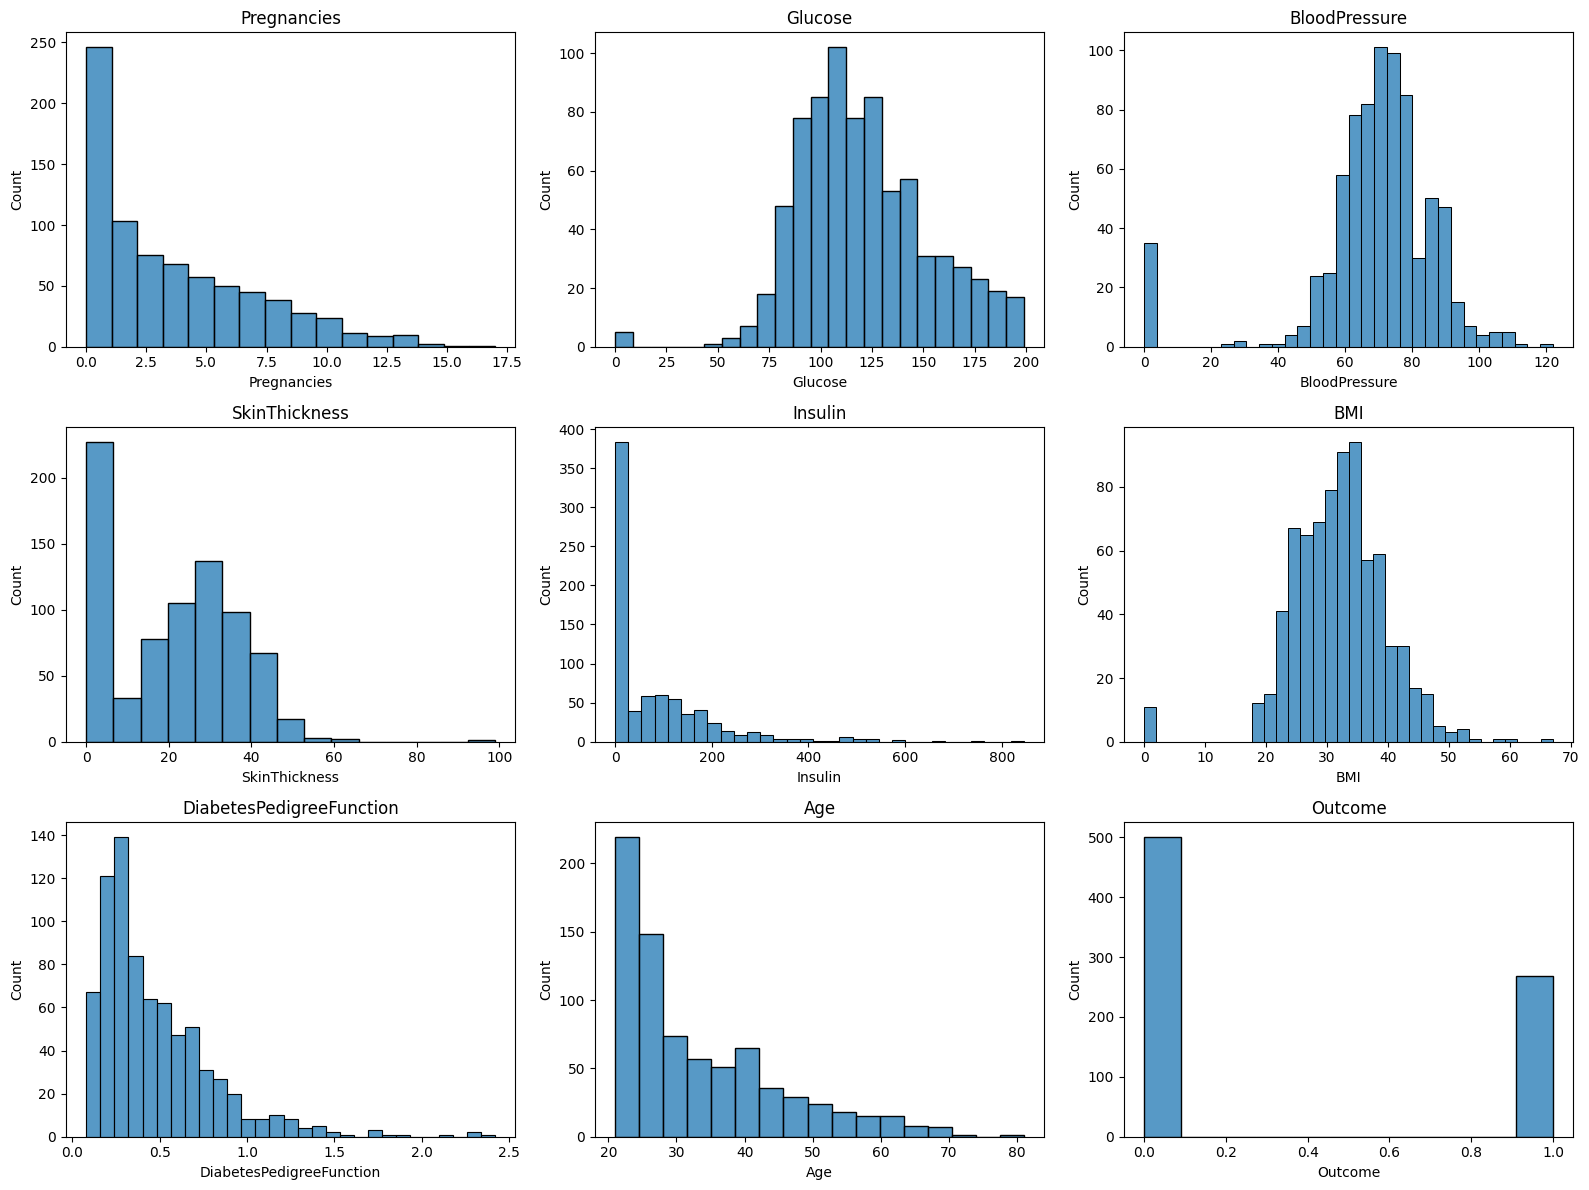

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

fig, axis = plt.subplots(3, 3, figsize=(16, 12))

for i, var in enumerate(variables):
    fila = i // 3
    col = i % 3
    sns.histplot(ax=axis[fila, col], data=total_data, x=var)
    axis[fila, col].set_title(var)

plt.tight_layout()
plt.show()


Existen valores nulos en variables como 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin' y 'BMI' por lo que supone existencia de datos faltantes.
>Por su naturaleza de las variables:
Númericas continuas: 'BMI', 'Glucose', 'BloodPressure'
Numéricas discretas: 'Pregnancies'
Categóricas binarias: 'Outcome' (YES/NO)
En este caso, la variable objetivo es 'Outcome'

Step 4: Análisis de Variable Multivariante

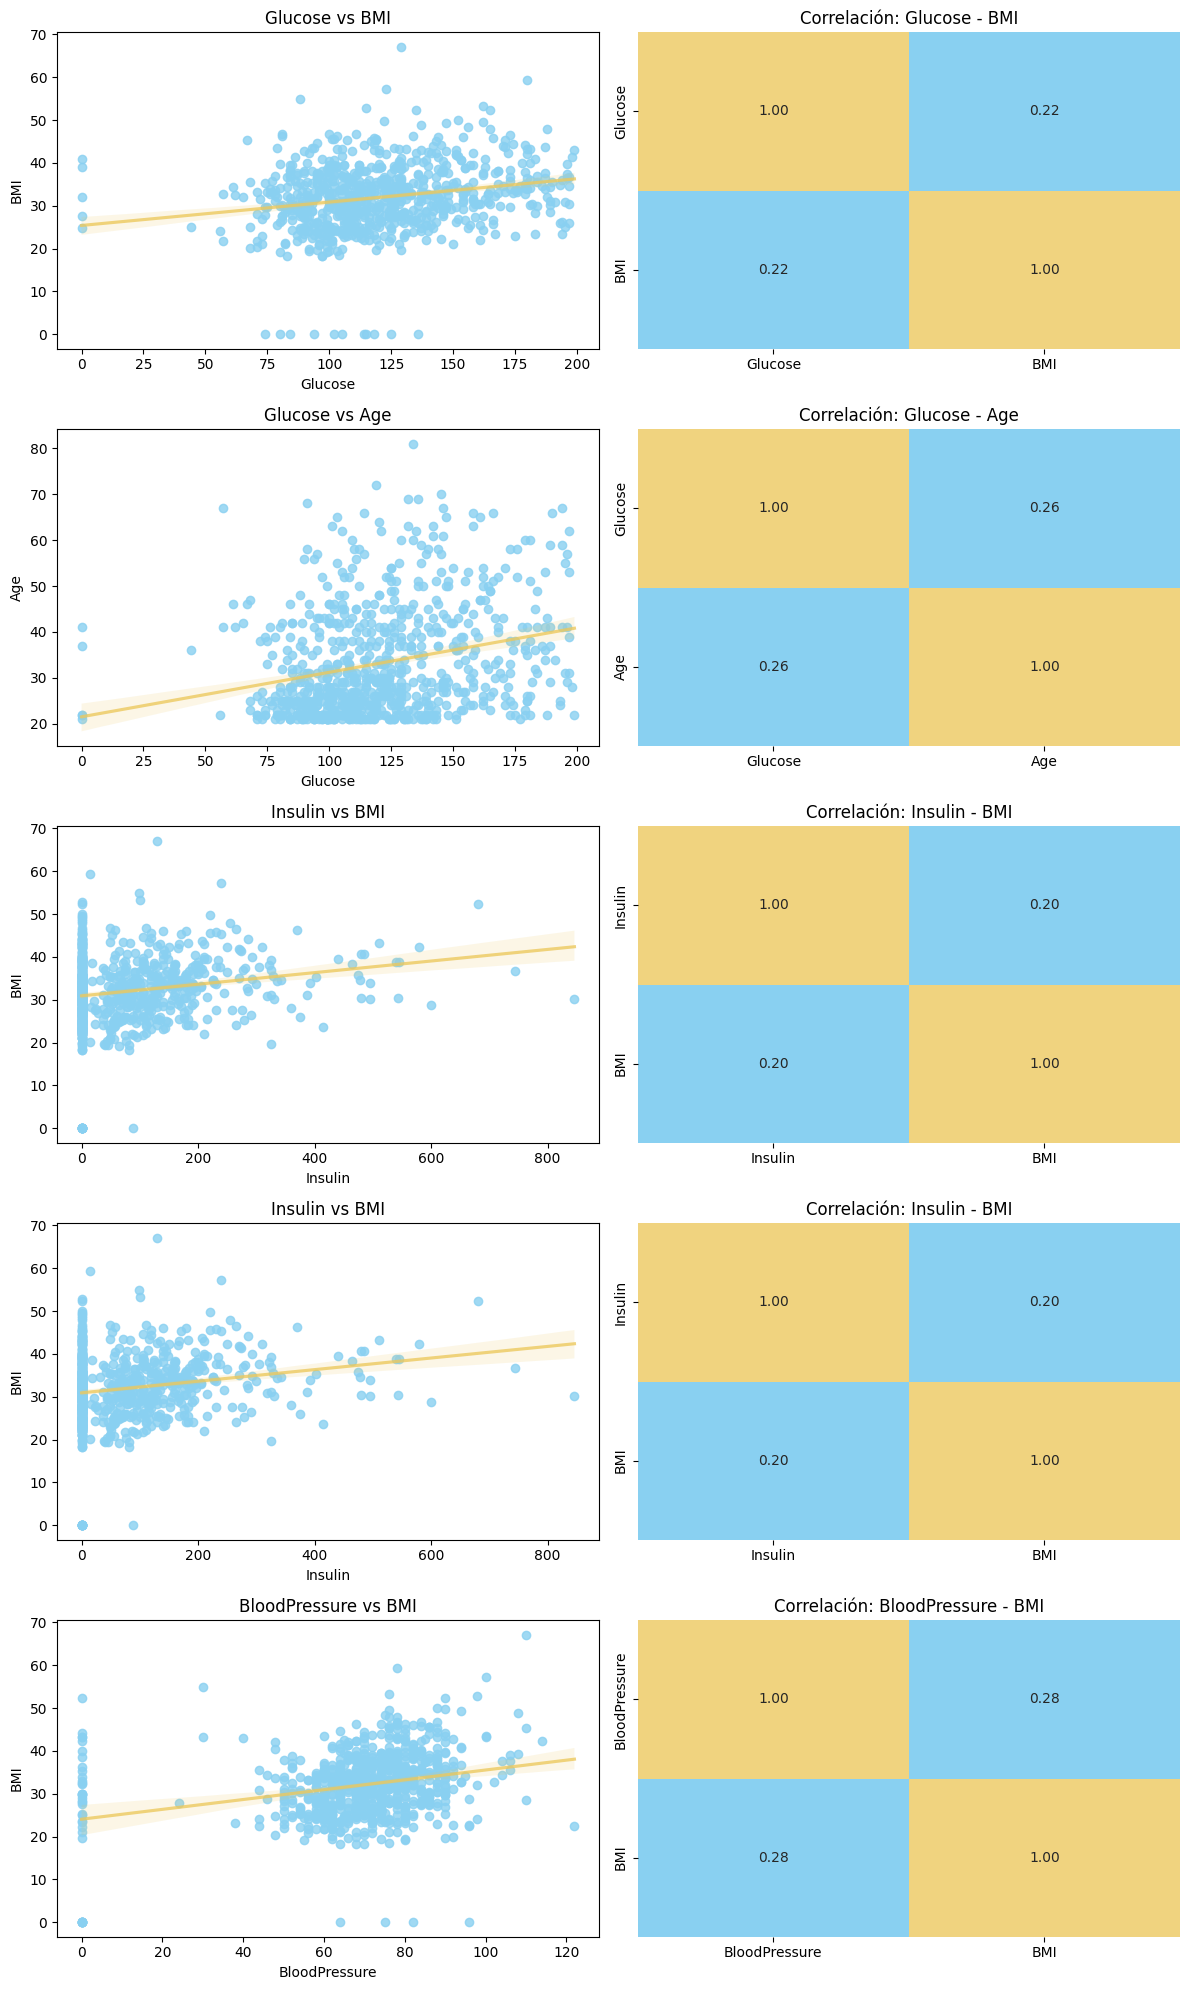

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pairs = [
    ("Glucose", "BMI"),
    ("Glucose", "Age"),
    ("Insulin", "BMI"),
    ("Insulin", "BMI"),
    ("BloodPressure", "BMI")
]

# Crear paleta celeste → blanco → ámbar
cmap_custom = LinearSegmentedColormap.from_list(
    "celeste_ambar",
    ["#89D0F1", "white", "#ECC85CC8"]
)

fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 4*len(pairs)))

for i, (x, y) in enumerate(pairs):

    # Regplot con colores personalizados
    sns.regplot(
        ax=axes[i, 0],
        data=total_data,
        x=x,
        y=y,
        scatter_kws={"color": "#89D0F1"},
        line_kws={"color": "#ECC85CC8"}
    )
    axes[i, 0].set_title(f"{x} vs {y}")

    # Heatmap con paleta personalizada
    corr = total_data[[x, y]].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap=cmap_custom,
        ax=axes[i, 1],
        cbar=False
    )
    axes[i, 1].set_title(f"Correlación: {x} - {y}")

plt.tight_layout()
plt.show()


INTERPRETACIÓN:
A mayor glucosa tiende a haber un IMC algo mayor, pero la relación más estrecha existe entre la Glucosa y la edad donde aumenta con tendencia ascendete conforme va teniendo más edad.

In [6]:
total_data["BMI_bin"] = pd.cut(
    total_data["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, 60],
    labels=["Bajo", "Normal", "Sobrepeso", "Obesidad I", "Obesidad II", "Obesidad III"]
)
total_data["Glucose_bin"] = pd.cut(
    total_data["Glucose"],
    bins=[0, 80, 100, 125, 150, 200, 300],
    labels=["<80", "80-100", "100-125", "125-150", "150-200", ">200"]
)

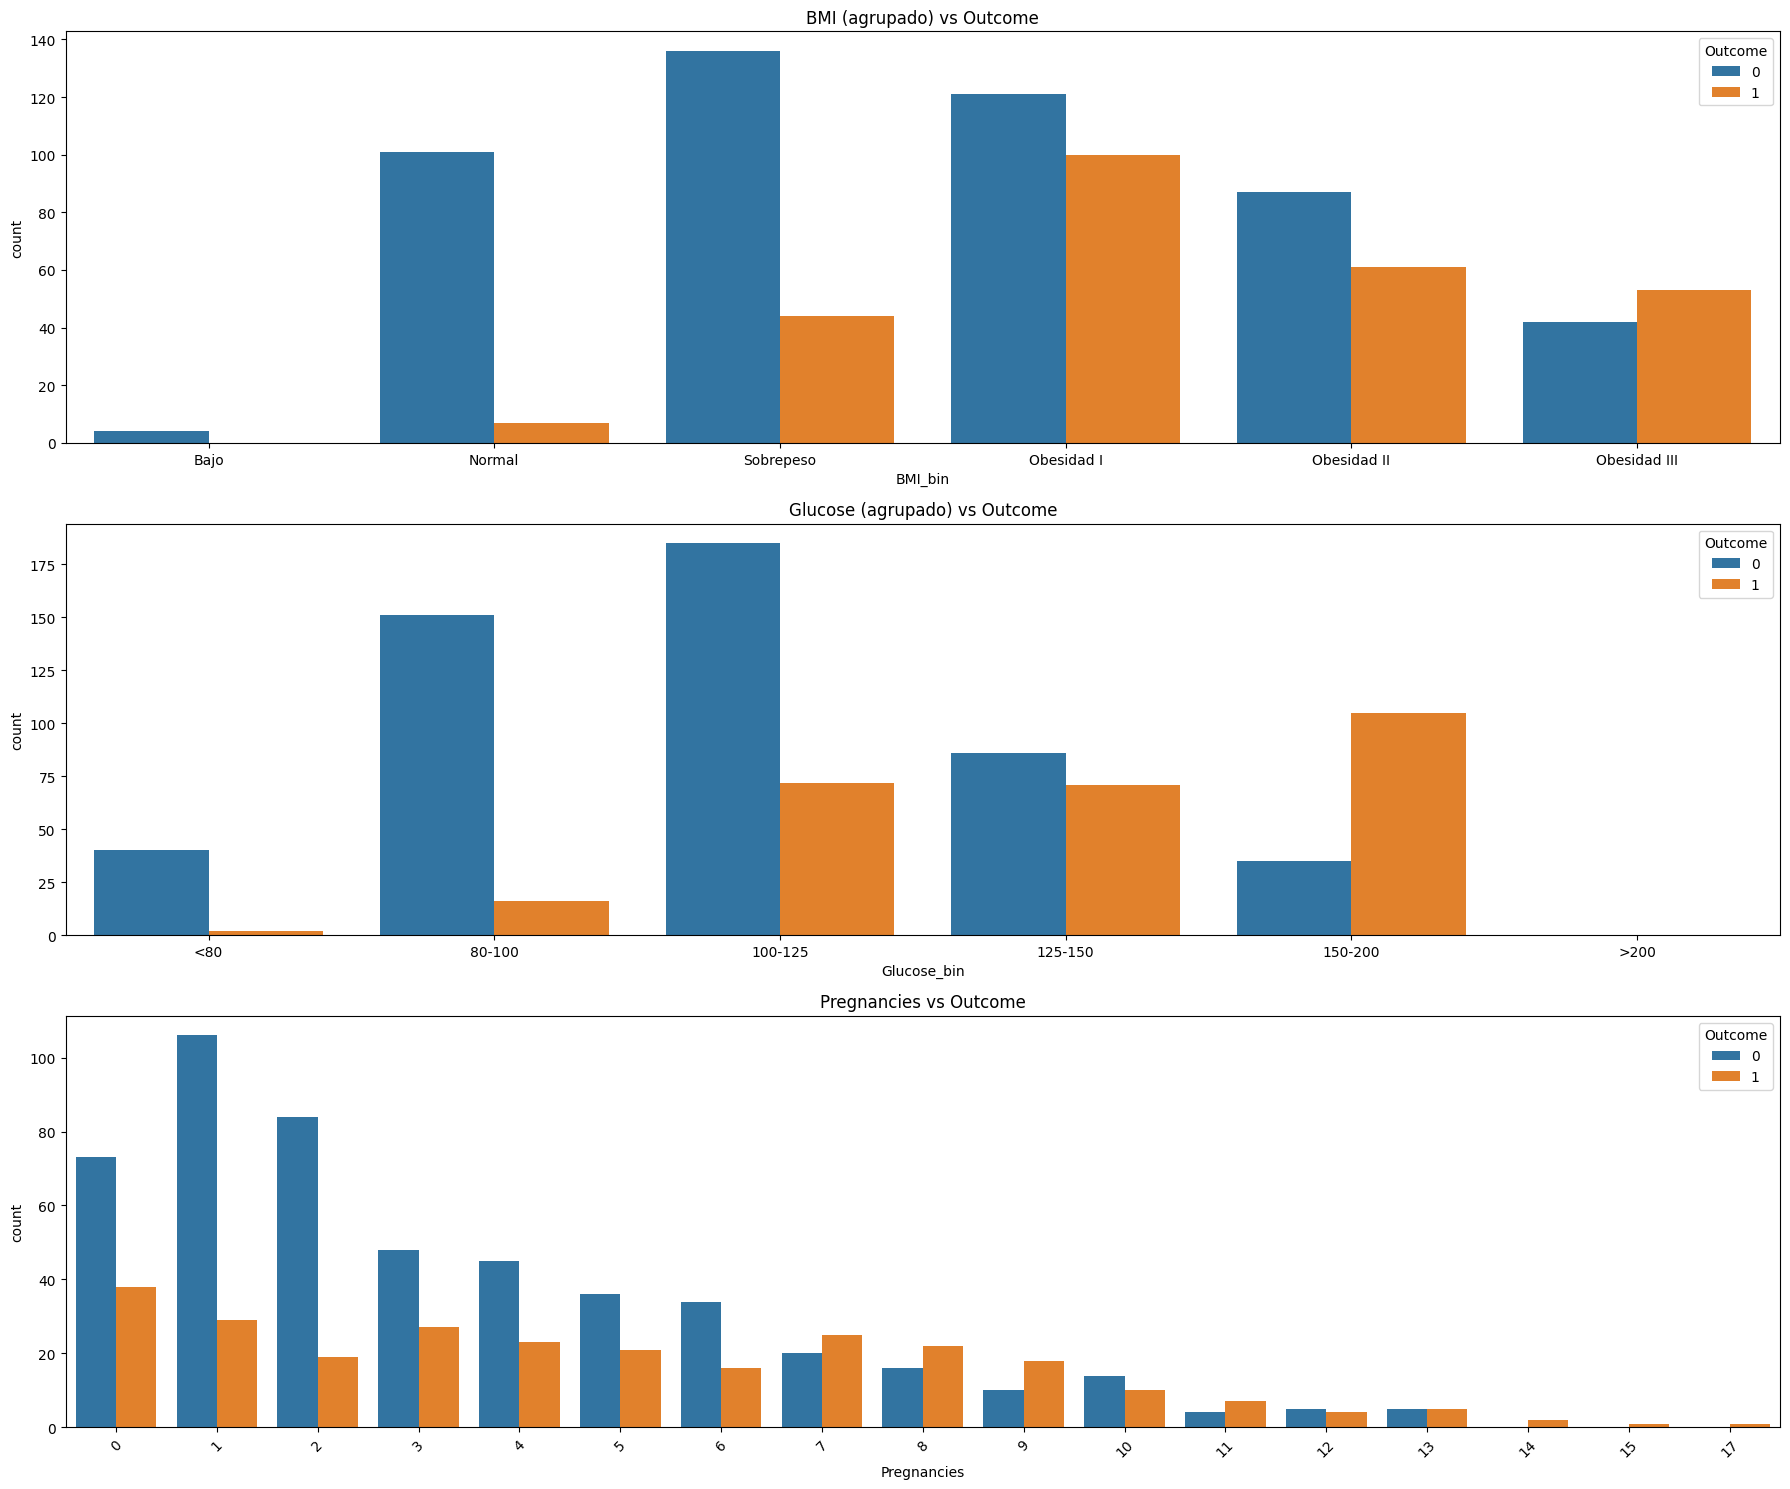

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

# Gráfico 1: BMI agrupado
sns.countplot(
    ax=axes[0],
    data=total_data,
    x="BMI_bin",
    hue="Outcome"
)
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_title("BMI (agrupado) vs Outcome")

# Gráfico 2: Glucose agrupado
sns.countplot(
    ax=axes[1],
    data=total_data,
    x="Glucose_bin",
    hue="Outcome"
)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_title("Glucose (agrupado) vs Outcome")

# Gráfico 3: Pregnancies (sin cambios)
sns.countplot(
    ax=axes[2],
    data=total_data,
    x="Pregnancies",
    hue="Outcome"
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title("Pregnancies vs Outcome")

plt.tight_layout()
plt.show()


En el Primer Gráfico de Barras - IMC: El exceso de peso se asocia con mayor riesgo metabólico de resultar con Diabetes
En el Segundo Gráfico de Barras - Glucose: Niveles altos de glucosa están estrechamente ligados al diagnóstico de diabetes, lo cual es coherente con los criterios clínicos habituales.
En el Tercer Gráfico de Barras - Pregnacies: Algunos estudios se observa que más embarazos pueden asociarse a mayor riesgo de diabetes tipo 2, en parte por la relación con diabetes gestacional previa.

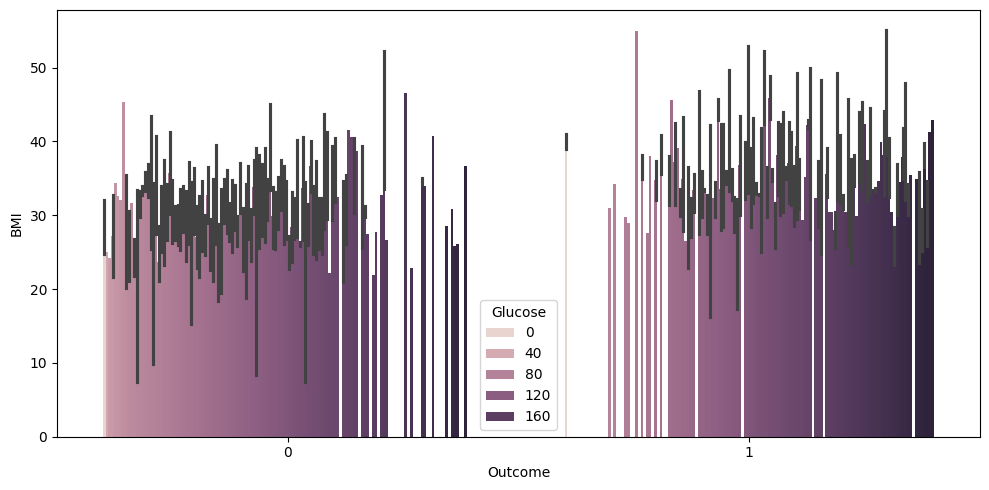

In [8]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.barplot(ax=axis, data=total_data, x="Outcome", y="BMI", hue="Glucose")

plt.tight_layout()
plt.show()

Conclusión:
Las personas sin diabetes tienden a tener BMI moderado y glucosa baja. Asimismo, las personas con diabetes tienden a tener tanto más peso como más glucosa. 

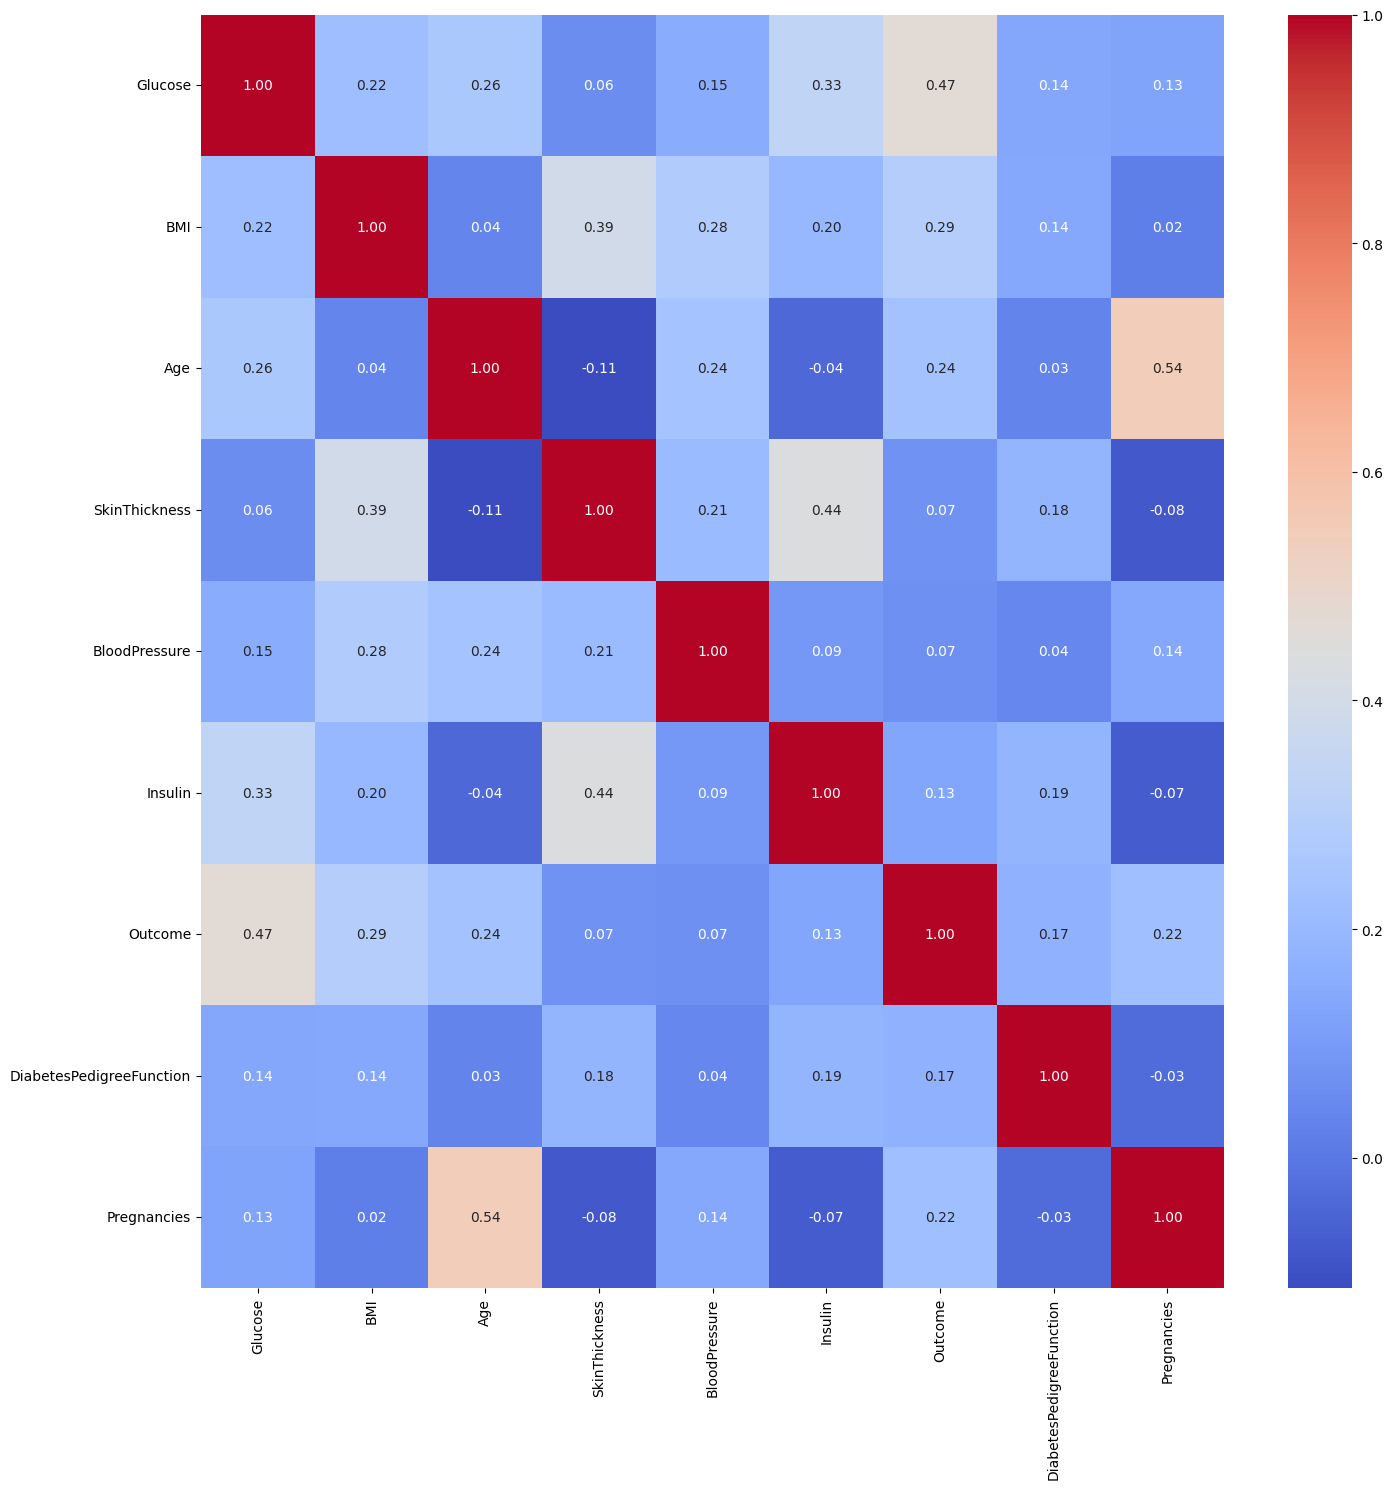

In [9]:
df_corr = total_data.copy()

# Dibujar el plot
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_corr[["Glucose", "BMI", "Age", "SkinThickness", "BloodPressure",
             "Insulin", "Outcome", "DiabetesPedigreeFunction", "Pregnancies"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.tight_layout()
plt.show()

Las variables que más se relacionan con el Outcome, con más riesgo de Diabetes son:

Glucose (la más fuerte con diferencia).

BMI (relación moderada).

Age y Pregnancies (relación moderada-baja).

El resto aporta información, pero con correlaciones bajas.

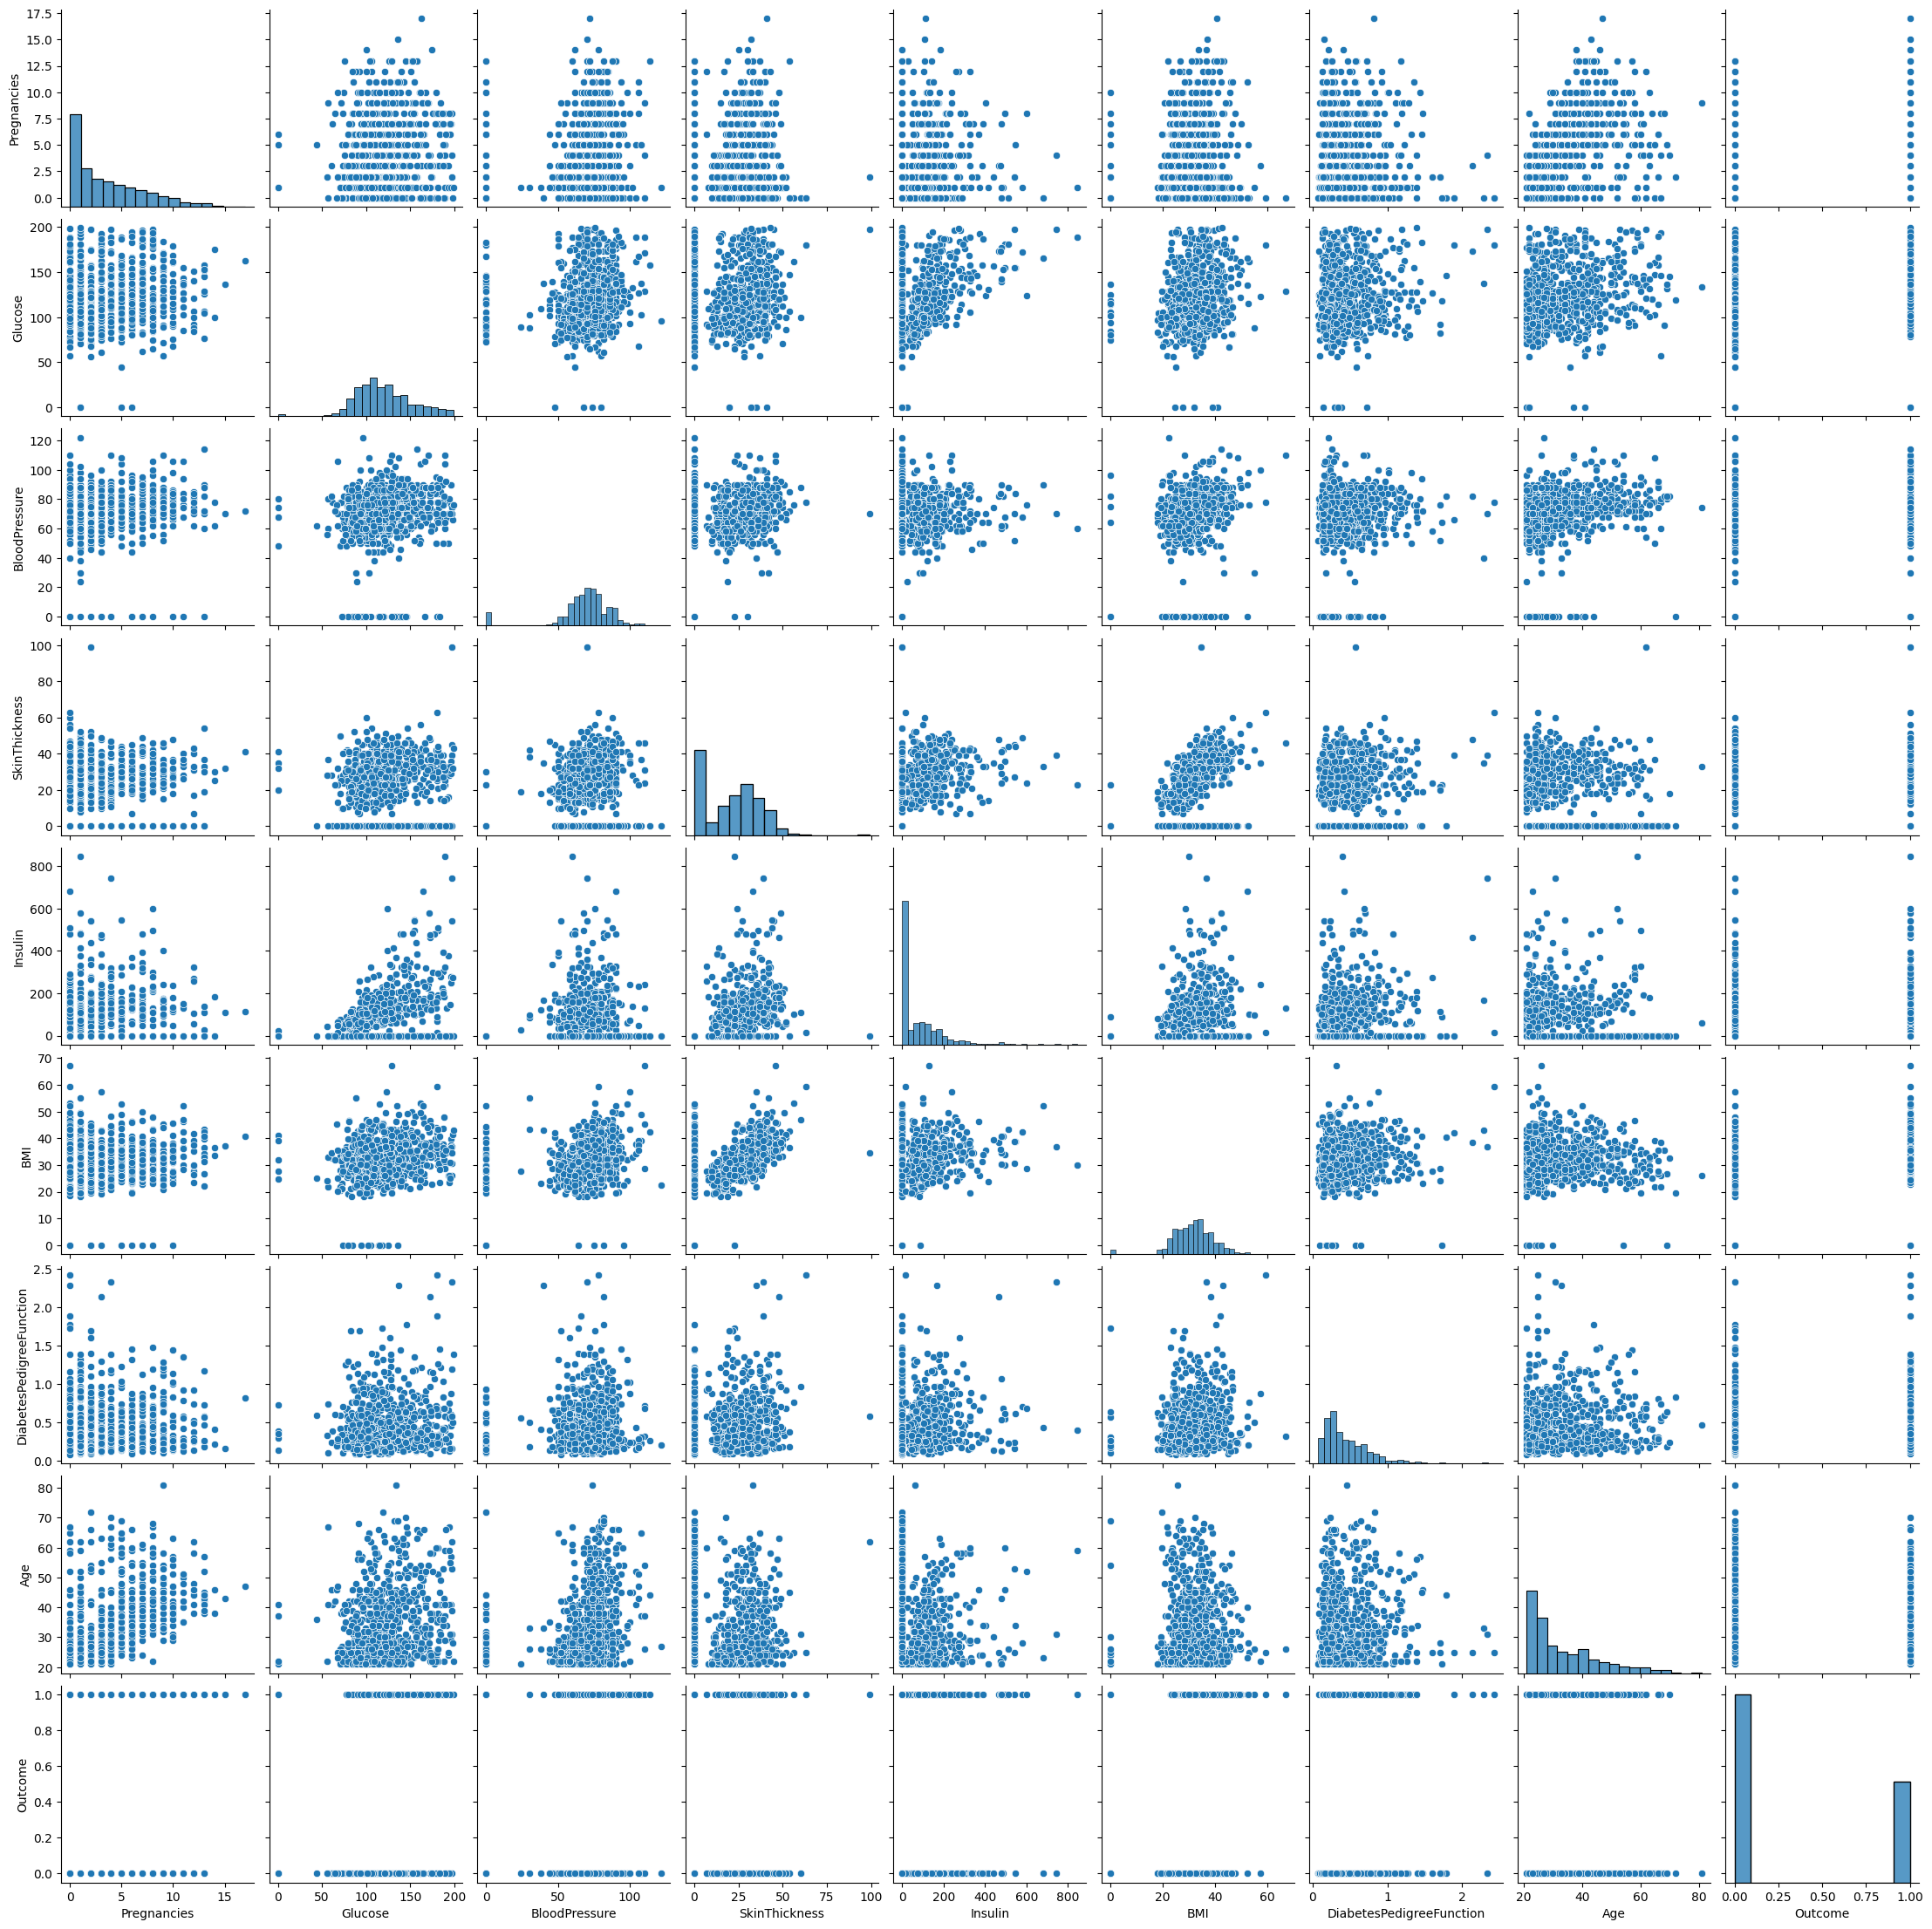

In [10]:
##ANÁLISIS DE TODA LA DATA EN UNA SOLA##
sns.pairplot(data = total_data)

Step 5: Ingeniería de Datos

In [11]:
total_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'Insulin', 'BMI', 'SkinThickness']

for col in cols:
    total_data[col] = total_data[col].replace(0, np.nan)


In [13]:
total_data = total_data.dropna(subset=cols)

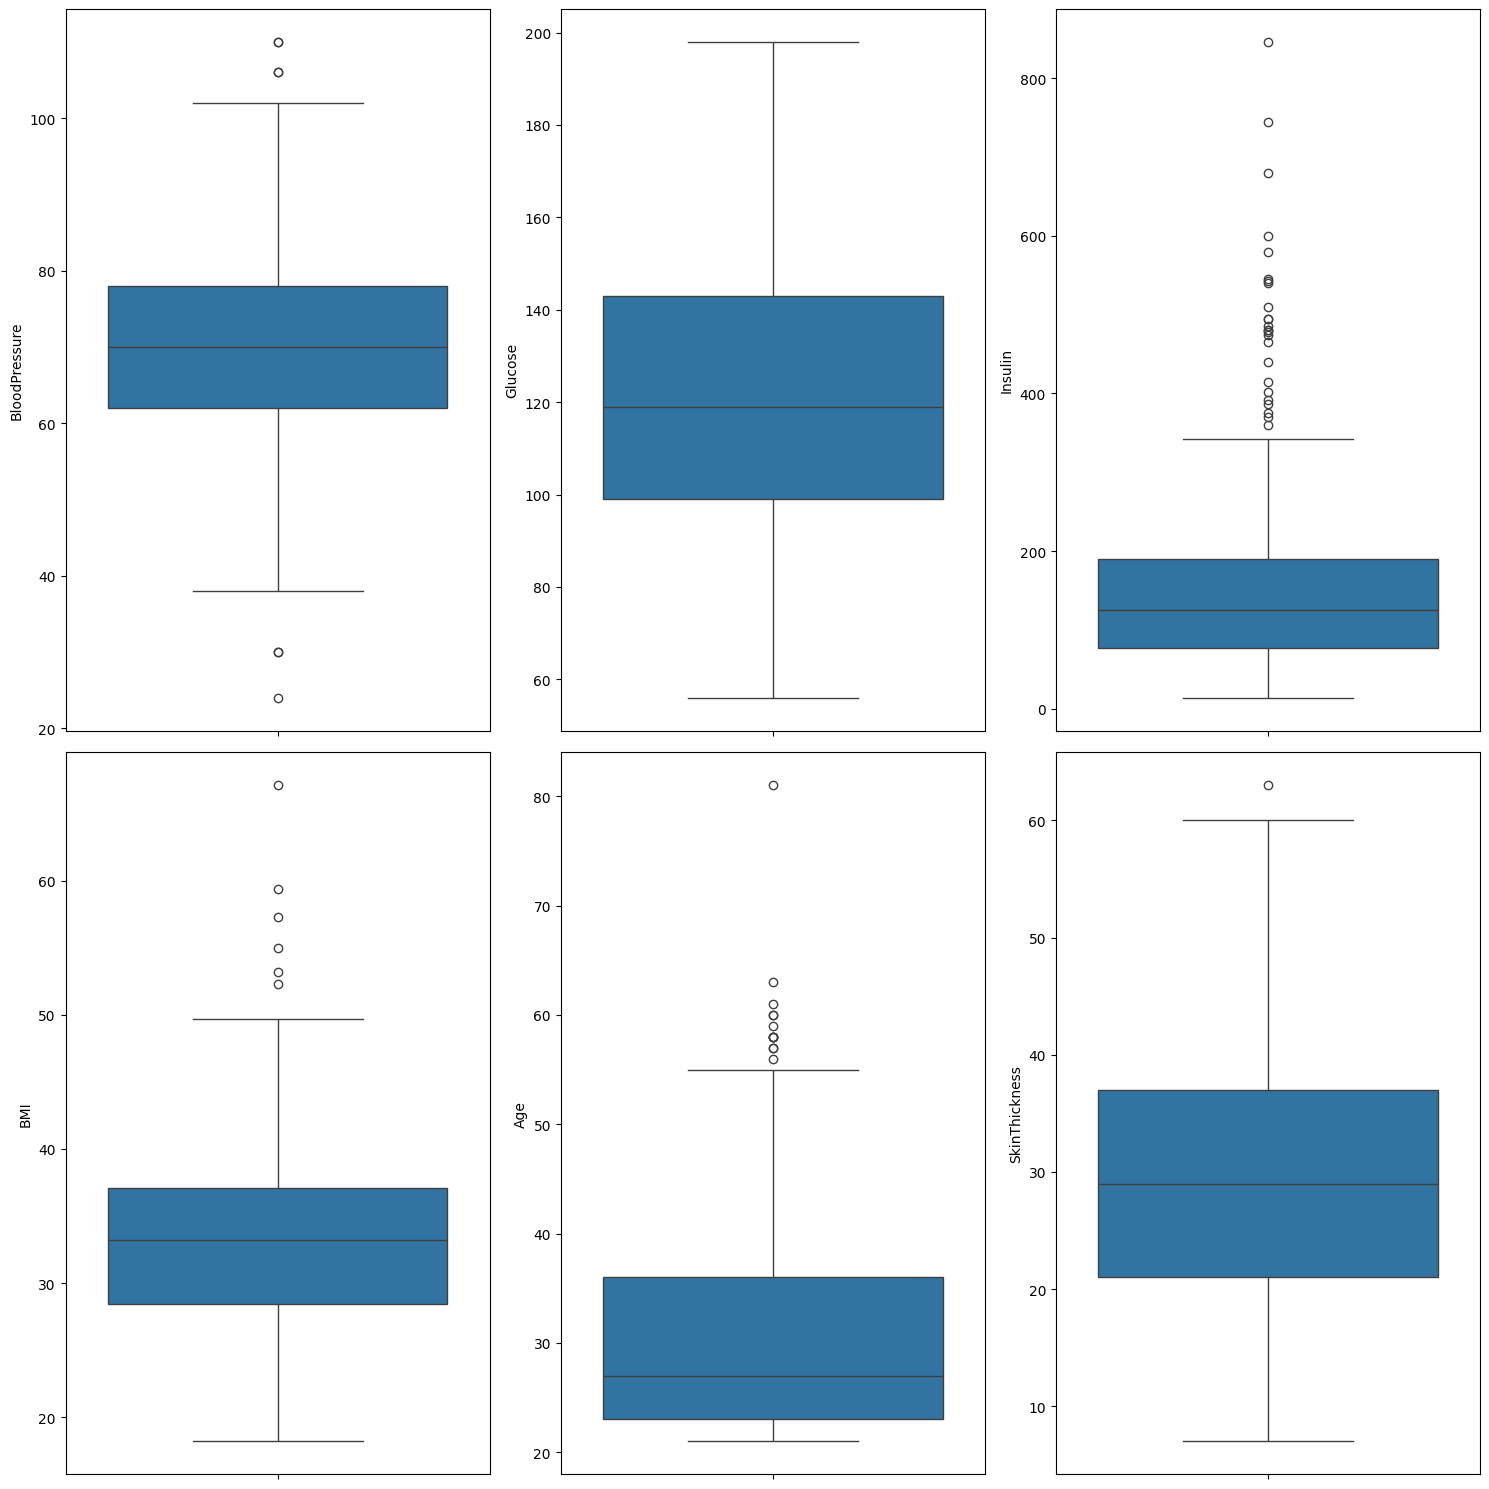

In [14]:
fig, axes = plt.subplots(2, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "BloodPressure")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "Glucose")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "Insulin")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "BMI")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "Age")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "SkinThickness")

plt.tight_layout()

plt.show()

Variables limpias: 'BMI' y 'Age', de las cuales se pueden trabajar sin necesidad e eliminar outliers

Variables con outliers moderados: variable 'Pregnancies'.

Variables con problemas de calidad (valores 0): 'Glucose', 'Insulin', 'SkinThickness'.

Variables con dispersión extrema: 'Insulin'.

In [15]:
# Stats for 'Pregnancies'
pregnancies_stats = total_data["Pregnancies"].describe()
pregnancies_stats

count    392.000000
mean       3.301020
std        3.211424
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [16]:
##Para la limpieza de outliers de BMI##
import numpy as np
total_data["log_BMI"] = np.log(total_data["BMI"])

In [17]:
# IQR para 'Pregnancies'

pregnancies_iqr = pregnancies_stats["75%"] - pregnancies_stats["25%"]
upper_limit = pregnancies_stats["75%"] + 1.5 * pregnancies_iqr
lower_limit = pregnancies_stats["25%"] - 1.5 * pregnancies_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(pregnancies_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 11.0 y -5.0, con un rango intercuartílico de 4.0


Hemos visto que para la variable 'Pregnancies', 'Glucose', 'Insulin' y 'SkinThickness' se requiere una limpieza de outliers

In [18]:
##Para la limpieza de outliers de la cola derecha, valores muy altos##
import numpy as np
max_allowed = 10  # por ejemplo
total_data['Pregnancies_capped'] = total_data['Pregnancies'].apply(lambda x: min(x, max_allowed))

Con este tipo de limpieza intento hacer lo siguiente: Sustituye todos los valores mayores que 10 por 10, ya sea que sea un valor >= que 10.

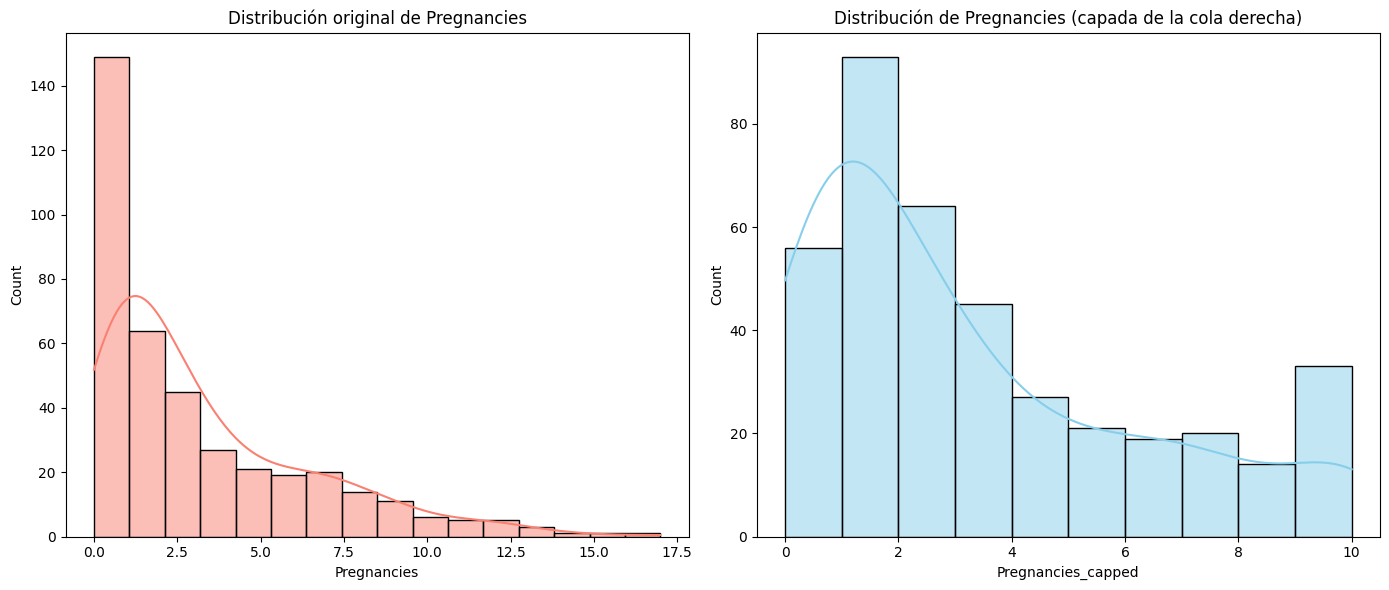

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear la variable capada (sin log)
max_allowed = 10
total_data["Pregnancies_capped"] = total_data["Pregnancies"].apply(lambda x: min(x, max_allowed))

# Graficar comparaciones
plt.figure(figsize=(14, 6))

# Distribución original
plt.subplot(1, 2, 1)
sns.histplot(total_data["Pregnancies"], kde=True, color="salmon")
plt.title("Distribución original de Pregnancies")
plt.xlabel("Pregnancies")

# Distribución capada
plt.subplot(1, 2, 2)
sns.histplot(total_data["Pregnancies_capped"], kde=True, color="skyblue")
plt.title("Distribución de Pregnancies (capada de la cola derecha)")
plt.xlabel("Pregnancies_capped")

plt.tight_layout()
plt.show()


In [20]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["Age", "BMI", "Glucose", "Insulin","BloodPressure", "Outcome"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'Age': [3.5, 55.5],
 'BMI': [15.35, 50.15],
 'Glucose': [33.0, 209.0],
 'Insulin': [14.0, 359.88],
 'BloodPressure': [38.0, 102.0],
 'Outcome': [0, 2.5]}

In [21]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [22]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

BMI_bin                     1
Glucose                     0
BloodPressure               0
SkinThickness               0
Pregnancies                 0
Insulin                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [23]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

BMI_bin                     1
Glucose                     0
BloodPressure               0
SkinThickness               0
Pregnancies                 0
Insulin                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [24]:
total_data_CON_outliers = total_data.copy()

cols = ["BMI", "Glucose"]
for col in cols:
    total_data_CON_outliers[col] = total_data_CON_outliers[col].fillna(total_data_CON_outliers[col].median())

# Recalcular variables derivadas
total_data_CON_outliers["BMI_bin"] = pd.cut(
    total_data_CON_outliers["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Bajo", "Normal", "Sobrepeso", "Obesidad"]
)

In [25]:
total_data_CON_outliers.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_bin                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [26]:
total_data_CON_outliers["BMI"] = total_data["BMI"]
total_data_SIN_outliers["BMI"] = total_data_SIN_outliers["BMI"]

In [27]:
total_data_CON_outliers["Glucose"] = total_data["Glucose"]
total_data_SIN_outliers["Glucose"] = total_data_SIN_outliers["Glucose"]

In [28]:
total_data_CON_outliers["Probabilidad"] = (
    total_data_CON_outliers["Glucose"] + total_data_CON_outliers["BMI"]
)

total_data_SIN_outliers["Probabilidad"] = (
    total_data_SIN_outliers["Glucose"] + total_data_SIN_outliers["BMI"]
)


In [29]:
import sklearn
from sklearn.model_selection import train_test_split

# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["Age", "BMI", "Glucose", "Insulin", "BloodPressure"]
target = ["Outcome"]

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)


In [30]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [31]:
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal.to_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers.to_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm.to_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal.to_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train.to_excel("../data/processed/y_train.xlsx")

In [32]:
import pandas as pd

X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers_norm = pd.read_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal = pd.read_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm = pd.read_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal = pd.read_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train = pd.read_excel("../data/processed/y_train.xlsx")

In [33]:
from sklearn.model_selection import train_test_split

# X = todas las columnas excepto el target
X = total_data.drop("Outcome", axis=1)

# y = el target
y = total_data["Outcome"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_bin,Glucose_bin,log_BMI,Pregnancies_capped
506,0,180.0,90.0,26.0,90.0,36.5,0.314,35,Obesidad II,150-200,3.597312,0
368,3,81.0,86.0,16.0,66.0,27.5,0.306,22,Sobrepeso,80-100,3.314186,3
345,8,126.0,88.0,36.0,108.0,38.5,0.349,49,Obesidad II,125-150,3.650658,8
134,2,96.0,68.0,13.0,49.0,21.1,0.647,26,Normal,80-100,3.049273,2
659,3,80.0,82.0,31.0,70.0,34.2,1.292,27,Obesidad I,<80,3.532226,3


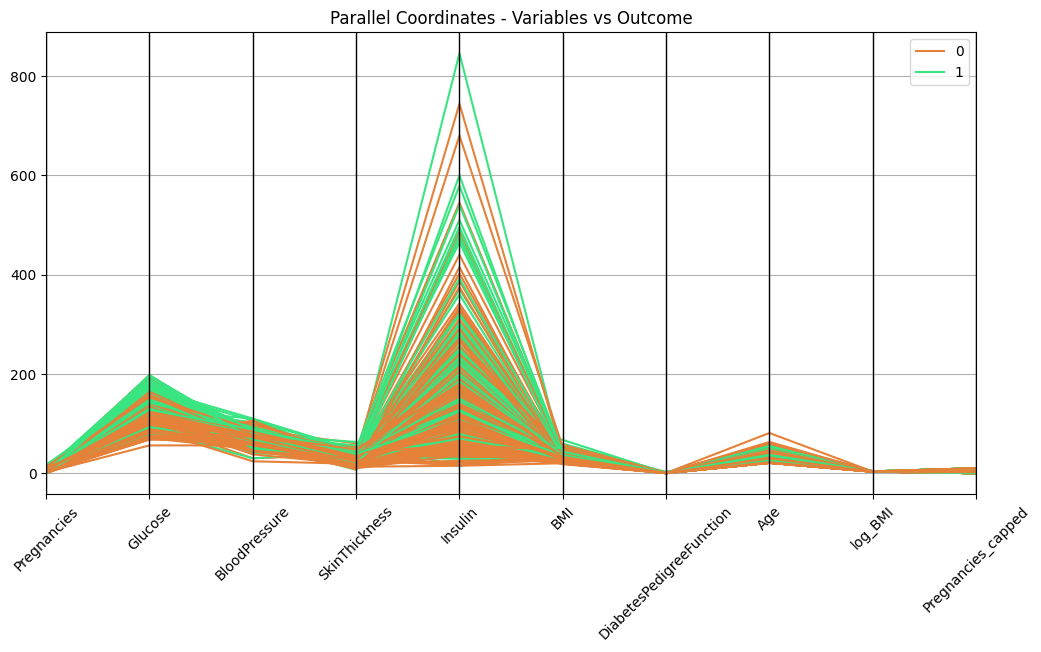

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = total_data.copy()

# Convertir el target a string para que funcione como clase
df_plot["Outcome"] = df_plot["Outcome"].astype(str)

# Seleccionar solo columnas numéricas
numeric_cols = df_plot.select_dtypes(include=["int64", "float64"]).columns

# Añadir el target a la lista de columnas permitidas
cols_to_plot = list(numeric_cols) + ["Outcome"]

df_plot = df_plot[cols_to_plot]

plt.figure(figsize=(12,6))
pd.plotting.parallel_coordinates(
    df_plot,
    "Outcome",
    color=("#E58139", "#39E581")
)
plt.xticks(rotation=45)
plt.title("Parallel Coordinates - Variables vs Outcome")
plt.show()

In [35]:
X = total_data.drop(columns=["Outcome", "BMI_bin", "Glucose_bin"])
y = total_data["Outcome"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

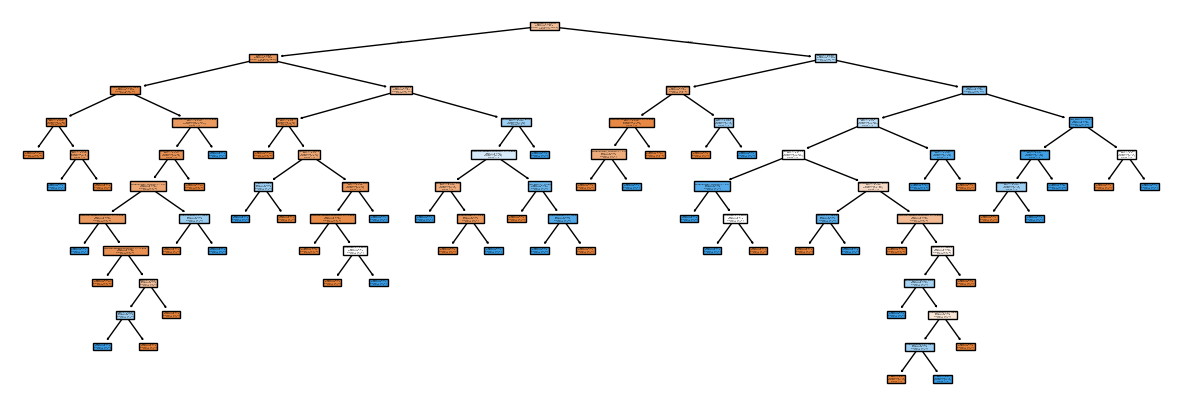

In [38]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(15,5))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)

plt.show()

In [39]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1])

In [40]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7215189873417721

In [41]:
from pickle import dump

dump(model, open("decision_tree_classifier_default_42.sav", "wb"))

In [43]:
train_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
test_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")

train_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [45]:
X_train = train_data.drop(["Outcome"], axis = 1)
y_train = train_data["Outcome"]
X_test = test_data.drop(["Outcome"], axis = 1)
y_test = test_data["Outcome"]

In [46]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state = 42)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [47]:
y_pred = model.predict(X_test)
y_pred

array([1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
       1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
       0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 0., 0., 0., 0.

In [48]:
from sklearn.metrics import mean_squared_error

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")

Error cuadrático medio: 0.0


In [49]:
dump(model, open("decision_tree_regressor_default_42.sav", "wb"))